In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("data/Sample - Superstore.csv")

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [4]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create monthly sales summary
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales = monthly_sales.reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

print(monthly_sales.head())

  Order Date      Sales
0    2014-01  14236.895
1    2014-02   4519.892
2    2014-03  55691.009
3    2014-04  28295.345
4    2014-05  23648.287


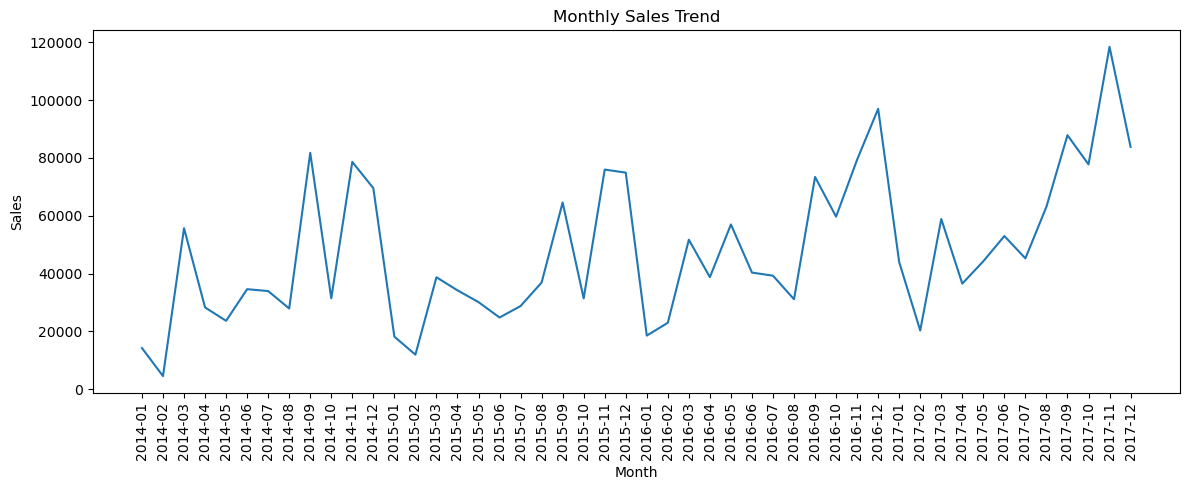

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Create month numbers
monthly_sales['Month_Number'] = np.arange(len(monthly_sales))

X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Predict next 12 months

future_months = np.arange(len(monthly_sales), len(monthly_sales) + 12).reshape(-1, 1)

future_predictions = model.predict(future_months)

print("Future Sales Predictions:")
print(future_predictions)

Future Sales Predictions:
[69957.53579787 70859.54333018 71761.55086249 72663.55839481
 73565.56592712 74467.57345943 75369.58099174 76271.58852405
 77173.59605636 78075.60358867 78977.61112098 79879.61865329]


c:\Users\ISHWRYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


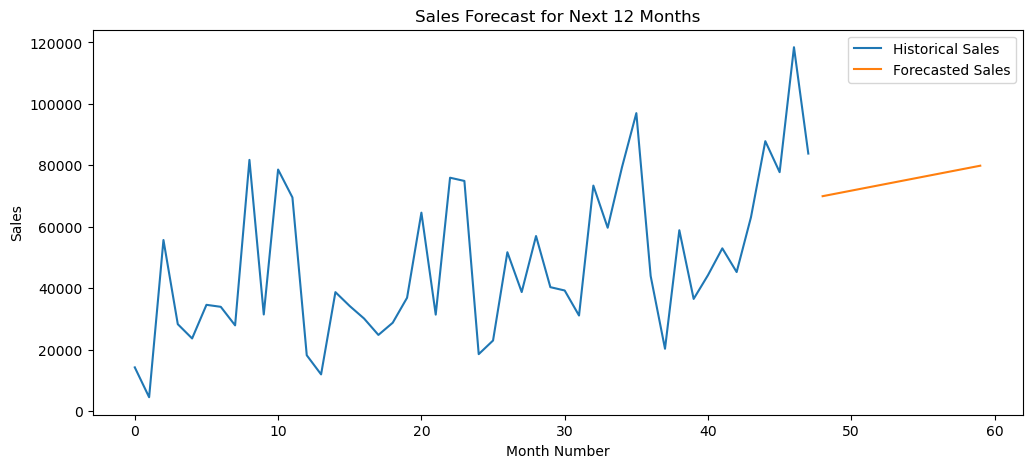

In [8]:
plt.figure(figsize=(12,5))

# Historical sales
plt.plot(monthly_sales['Month_Number'],
         monthly_sales['Sales'],
         label='Historical Sales')

# Future forecast
plt.plot(future_months,
         future_predictions,
         label='Forecasted Sales')

plt.title("Sales Forecast for Next 12 Months")
plt.xlabel("Month Number")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predictions on existing data
predictions = model.predict(X)

# Calculate errors
mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

Mean Absolute Error (MAE): 17457.725724823373
Mean Squared Error (MSE): 465460447.0806553


In [ ]:
print("""
Business Insights:
1. Sales show an overall increasing trend over time.
2. The forecasting model predicts continued sales growth.
3. Forecast results can help businesses plan inventory and resources.
4. Future sales are estimated to be between 70,000 and 80,000 units/revenue levels over the next year.
""")